In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-testing-master.csv
/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-training-master.csv


In [2]:
df_test = pd.read_csv('/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-testing-master.csv')
df_train = pd.read_csv('/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-training-master.csv')

In [3]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df_test.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


test data have target variable too.. -> "Churn"

# EDA

In [5]:
df_train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [6]:
df_train[df_train.isnull().any(axis = 1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_train = df_train.drop(index =199295 )

In [8]:
df_train.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [9]:
df_test.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


In [11]:
cat_column = df_train.select_dtypes(include=['object','category']).columns.tolist() #faster, uses pandas build-in function
num_col = df_train.select_dtypes(exclude=['object','category']).columns.tolist()

In [12]:
print(cat_column)
print(num_col)

['Gender', 'Subscription Type', 'Contract Length']
['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']


In [13]:
for col in cat_column:
    #Counting unique values in each row
    print(f"Total number of unique value in {col} is {df_train[col].nunique()}")

    #creating a table!
    count = df_train[col].value_counts()
    percentage = df_train[col].value_counts(normalize=True)*100

    summary_df = pd.DataFrame({
        'Count' : count ,
        'Percentage' : percentage
    })

    print(summary_df)
    print('*'*90)
    print()
    

Total number of unique value in Gender is 2
         Count  Percentage
Gender                    
Male    250252   56.768111
Female  190580   43.231889
******************************************************************************************

Total number of unique value in Subscription Type is 3
                    Count  Percentage
Subscription Type                    
Standard           149128   33.828760
Premium            148678   33.726680
Basic              143026   32.444559
******************************************************************************************

Total number of unique value in Contract Length is 3
                  Count  Percentage
Contract Length                    
Annual           177198   40.196265
Quarterly        176530   40.044734
Monthly           87104   19.759001
******************************************************************************************



In [35]:
# Calculate correlation for all numerical columns against Churn at once
result = df_train[num_col].corrwith(df_train['Churn']).round(3).reset_index()

# Rename the columns to match your desired output
result.columns = ['column_name', 'correlation']

print(result)


        column_name  correlation
0        CustomerID       -0.839
1               Age        0.218
2            Tenure       -0.052
3   Usage Frequency       -0.046
4     Support Calls        0.574
5     Payment Delay        0.312
6       Total Spend       -0.429
7  Last Interaction        0.150
8             Churn        1.000


# Feature Engineering

In [15]:
# Making Pipeline for easy transformation!

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse_output=False), ['Subscription Type']), 
        
        ('ordinal', OrdinalEncoder(categories=[['Monthly', 'Quarterly', 'Annual']]), ['Contract Length']),
        
        ('binary', OrdinalEncoder(categories=[['Female', 'Male']]), ['Gender'])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False
)


# Training & Evaluation

In [16]:
# Step1: Define X and y
X_train = df_train.drop(columns = ['CustomerID','Churn'])
y_train = df_train['Churn']

X_test = df_test.drop(columns = ['CustomerID','Churn'])
y_test = df_test['Churn']


In [17]:
# Step 2: Create Pipeline for transformation of X and y, and model selction
import lightgbm as lgb
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        boosting_type='gbdt',
        num_leaves=31,
        max_depth=-1,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42

))
])

In [18]:
# Step 3: Cross Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc'
    ]
)



[LightGBM] [Info] Number of positive: 199999, number of negative: 152666
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 352665, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567108 -> initscore=0.270060
[LightGBM] [Info] Start training from score 0.270060


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 199999, number of negative: 152666
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 352665, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567108 -> initscore=0.270060
[LightGBM] [Info] Start training from score 0.270060


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 199999, number of negative: 152667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567106 -> initscore=0.270053
[LightGBM] [Info] Start training from score 0.270053


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 199999, number of negative: 152667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005931 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567106 -> initscore=0.270053
[LightGBM] [Info] Start training from score 0.270053


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 200000, number of negative: 152666
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567109 -> initscore=0.270065
[LightGBM] [Info] Start training from score 0.270065


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
# Step 4: Check Result of cv

for metric, scores in results.items():
    if metric.startswith('test_'):
        print(f"{metric}: {scores.mean():.4f}")

test_accuracy: 0.9998
test_precision: 0.9999
test_recall: 0.9997
test_f1: 0.9998
test_roc_auc: 1.0000


In [20]:
# Step 5: Train on FULL training set

model.fit(X_train, y_train) # fit means fit_transform internally in pipeline

[LightGBM] [Info] Number of positive: 249999, number of negative: 190833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 440832, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567107 -> initscore=0.270058
[LightGBM] [Info] Start training from score 0.270058


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Subscription Type']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Annual']]),
                                                  ['Contract Length']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['Female',
                                                                              'Male']]),
                                                  ['Gender'])],
                                   verbose_feature_names_out=False)),
                ('classifier', LGBMClassifier(random_state=42))])

In [21]:
# Step 6: Evaluate on Test Set

y_pred = model.predict(X_test) # Predict means transform internally in pipeline


from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


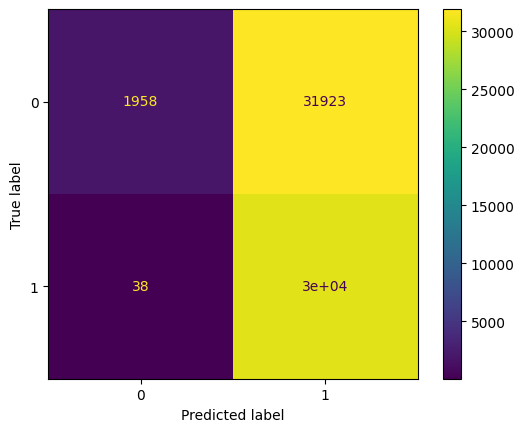

In [22]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

In [23]:
df_train.duplicated().sum()

np.int64(0)